# **Klasifikasi Tumor Jinak atau Ganas | Logistic Regression**

Model klasifikasi kanker payudara termasuk tumor jinak atau ganas menggunakan algoritma Logistic Regression.

## 1. Data Understanding & Explratory Data Analysis

### 1.1 Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Understanding Data

In [2]:
# import dataset
cancer = pd.read_csv('breast-cancer.csv')

In [3]:
# Tamplikan 5 baris teratas dataset
print('\n5 baris teratas:')
cancer.head()


5 baris teratas:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
# Tampilkan informasi dataset
print('\nInformasi dataset:')
cancer.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perime

In [5]:
# Tampilkan dimensi dataset
print('\nDimensi dataset:')
print('Jumlah baris:', cancer.shape[0])
print('Jumlah kolom:', cancer.shape[1])


Dimensi dataset:
Jumlah baris: 569
Jumlah kolom: 32


In [6]:
# Tampilkan nilai unik dan jumlahnya per fitur
for col in cancer.columns:
    print(f'=== Fitur {col} ===')
    print('\nJumlah nilai unik :', cancer[col].nunique())
    print('Nilai unik:', cancer[col].unique())

=== Fitur id ===

Jumlah nilai unik : 569
Nilai unik: [   842302    842517  84300903  84348301  84358402    843786    844359
  84458202    844981  84501001    845636  84610002    846226    846381
  84667401  84799002    848406  84862001    849014   8510426   8510653
   8510824   8511133    851509    852552    852631    852763    852781
    852973    853201    853401    853612  85382601    854002    854039
    854253    854268    854941    855133    855138    855167    855563
    855625    856106  85638502    857010  85713702     85715    857155
    857156    857343    857373    857374    857392    857438  85759902
    857637    857793    857810    858477    858970    858981    858986
    859196  85922302    859283    859464    859465    859471    859487
    859575    859711    859717    859983   8610175   8610404   8610629
   8610637   8610862   8610908    861103   8611161   8611555   8611792
   8612080   8612399  86135501  86135502    861597    861598    861648
    861799    861853   

[0.2776  0.07864 0.1599  0.2839  0.1328  0.17    0.109   0.1645  0.1932
 0.2396  0.06669 0.1292  0.2458  0.1002  0.2293  0.1595  0.072   0.2022
 0.1027  0.08129 0.127   0.06492 0.2135  0.1022  0.1457  0.2276  0.1868
 0.1066  0.1697  0.1157  0.1887  0.1516  0.1496  0.1719  0.1559  0.1336
 0.1098  0.03766 0.05131 0.1255  0.06031 0.1218  0.219   0.1436  0.1047
 0.1686  0.05943 0.1231  0.09092 0.07698 0.04966 0.06059 0.04751 0.1485
 0.07081 0.05473 0.1267  0.1365  0.03789 0.05272 0.08061 0.08963 0.2008
 0.08751 0.1262  0.1479  0.07773 0.04701 0.1413  0.05234 0.1029  0.1531
 0.183   0.128   0.06829 0.08424 0.2146  0.3454  0.09546 0.09362 0.1535
 0.2665  0.1791  0.07165 0.1053  0.09947 0.1206  0.09445 0.1339  0.08606
 0.1036  0.05055 0.08165 0.1553  0.1313  0.07057 0.05301 0.07525 0.1141
 0.08511 0.07568 0.04038 0.09697 0.08578 0.1765  0.1017  0.06815 0.2768
 0.06575 0.08404 0.1209  0.2233  0.1303  0.08201 0.07849 0.1243  0.1649
 0.1752  0.06722 0.06685 0.11    0.2867  0.1099  0.07325 0.0613

In [7]:
# Fungsi menampilkan nilai unik dan jumlahnya 
def unique_values(feature_name):
    print(f'\n=== Nilai unik fitur {feature_name} ===')
    print('Jumlah nilai unik:', cancer[feature_name].nunique(),'\n')
    print('Nilai unik:', cancer[feature_name].unique())

In [8]:
# Tampilkan fitur
print('Kolom di dataset:')
cancer.columns 

Kolom di dataset:


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [9]:
# Panggil fungsi 
unique_values('diagnosis')


=== Nilai unik fitur diagnosis ===
Jumlah nilai unik: 2 

Nilai unik: ['M' 'B']


In [10]:
# Hapus fitur 'Id'
cancer = cancer.drop('id', axis=1)

In [11]:
# Tampilkan 5 baris teratas setelah 'id' dihapus
cancer.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [12]:
# Encoding fitur target
cancer['diagnosis'] = cancer['diagnosis'].map({
    'M': 0,
    'B': 1
})

### 1.3 Missing Value dan Baris Duplikat

#### 1.3.1 Missing Value

In [13]:
# Tamplikan total missing value
print('Total missing value:', cancer.isnull().sum().sum())

Total missing value: 0


#### 1.3.2 Baris Duplikat

In [14]:
# Tampilkan total baris duplikat
print('Total baris duplikat:', cancer.duplicated().sum())

Total baris duplikat: 0


### 1.4 Exploratory Data Analysis

#### 1.4.1 Statistik Dataset

In [15]:
# Tamplikan statistik dataset
cancer.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.627417,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,1.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Ada beberapa fitur yang memiliki nilai maximal yang cukup jauh dari mediannya. Seperti fitur 'area_mean' dan 'area_worst'. Ini ada kemungkinan terdapat outlier didalammnya.

#### 1.4.2 Penyebaran Data

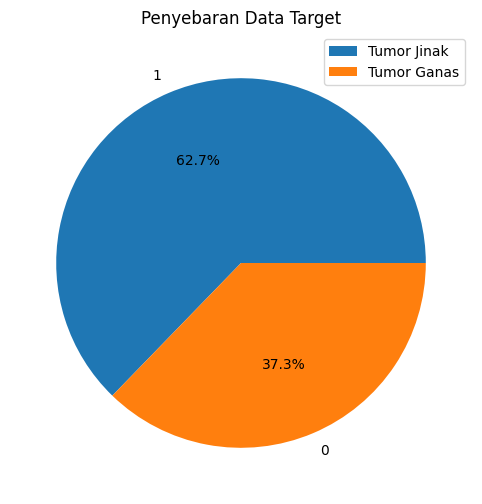

In [16]:
# Tampilkan penyebaran data target
plt.figure(figsize=(8, 6))
plt.pie(cancer['diagnosis'].value_counts(), labels=cancer['diagnosis'].value_counts().index, autopct='%1.1f%%')
plt.title('Penyebaran Data Target')
plt.legend(['Tumor Jinak', 'Tumor Ganas'])
plt.show()

Penyebaran data target, cukup tidak seimbang, dengan tumor jinak mendominasi. Kita membutuhkan resampling, supaya tidak bias ke mayoritas.

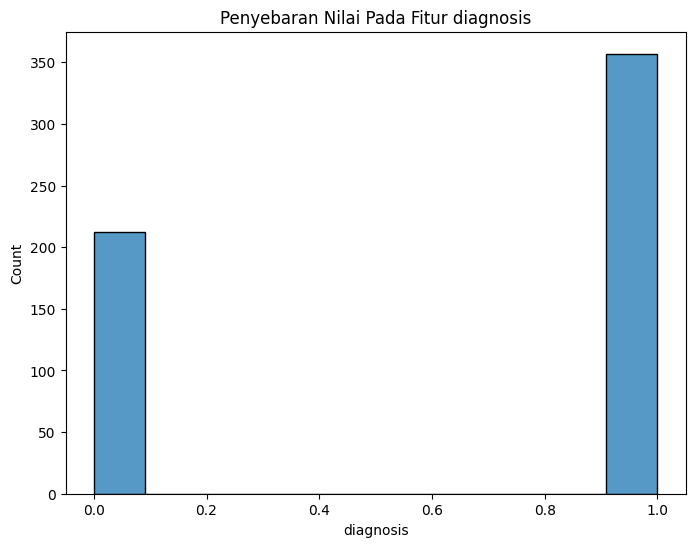

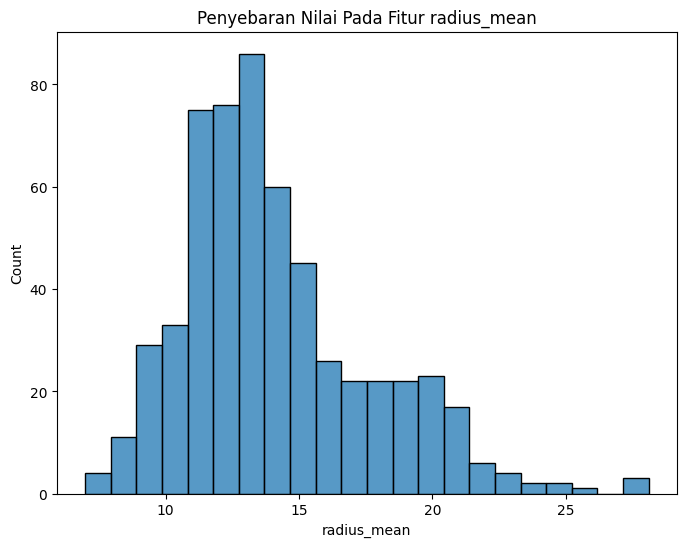

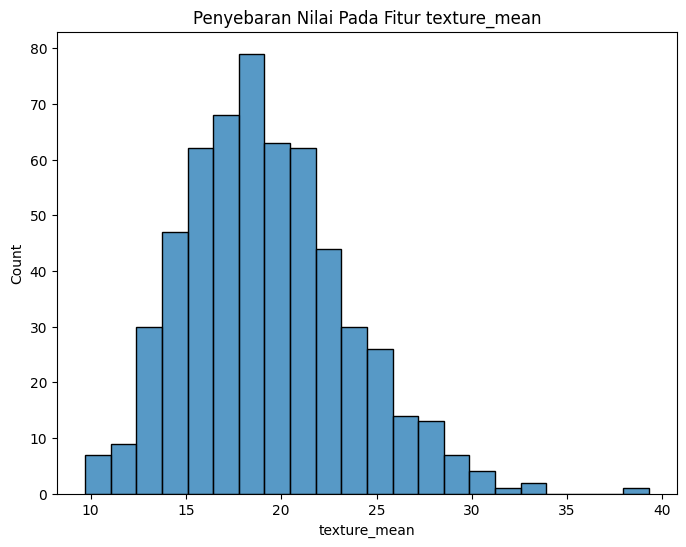

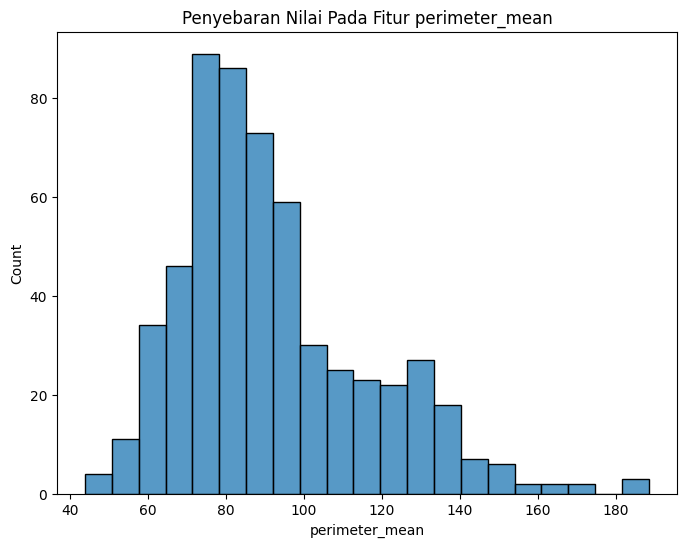

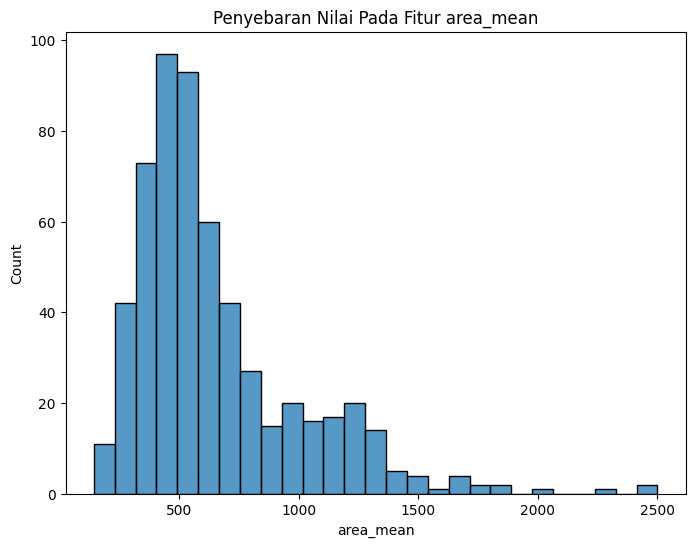

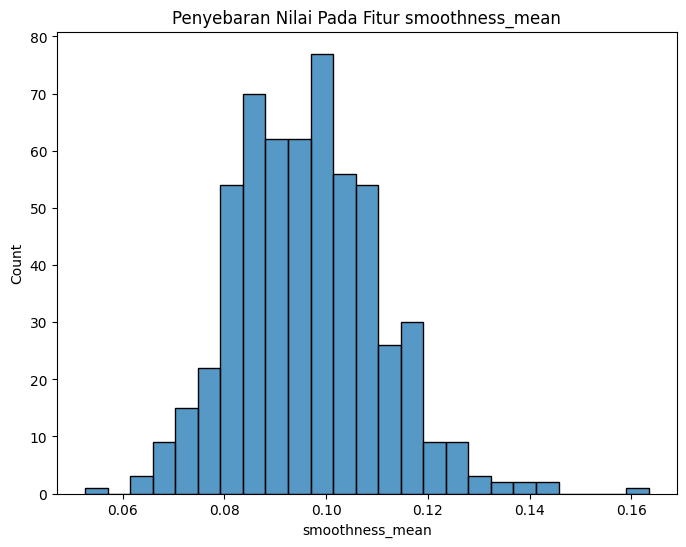

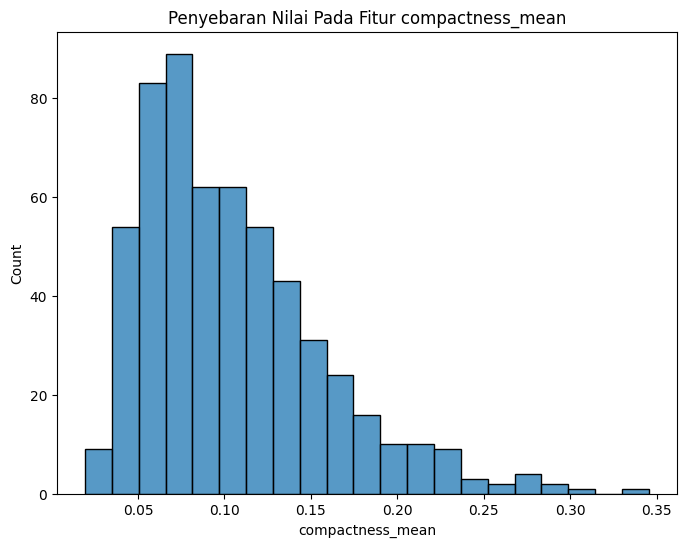

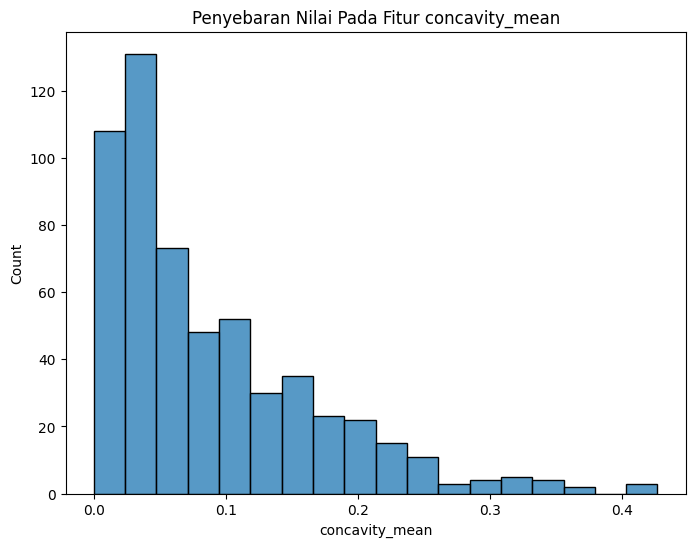

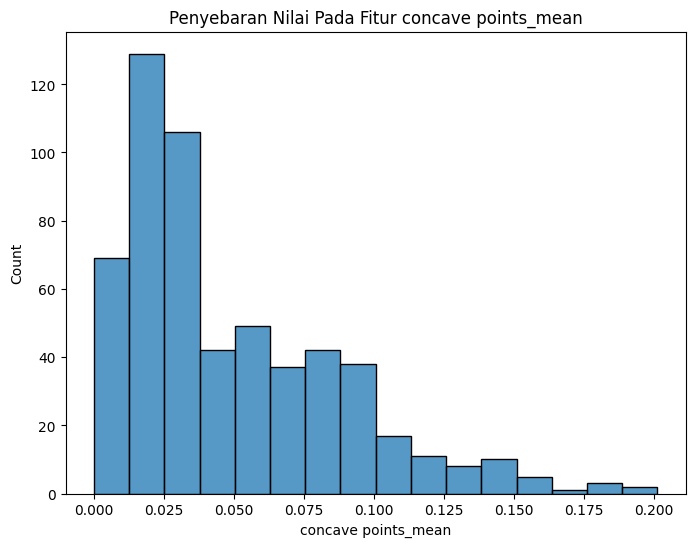

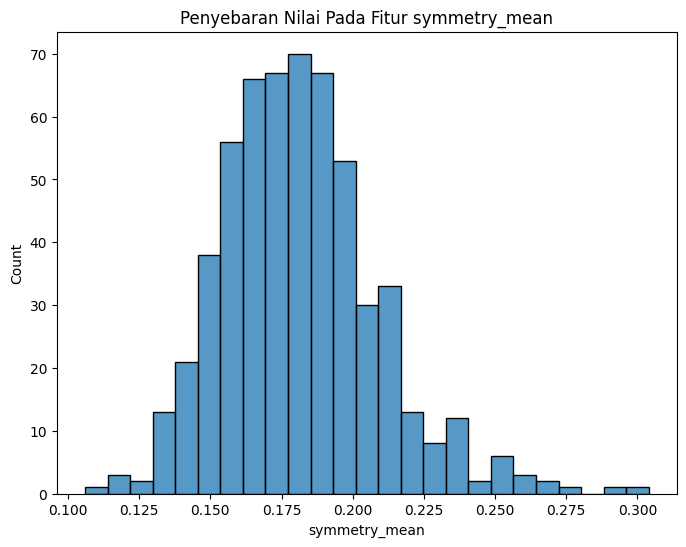

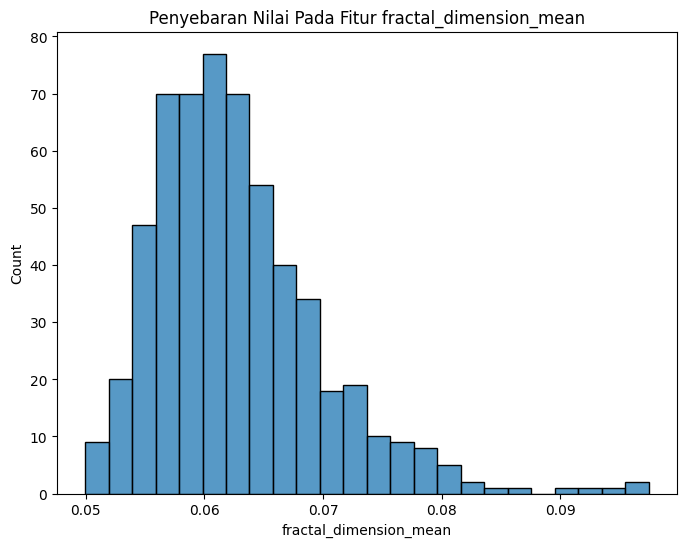

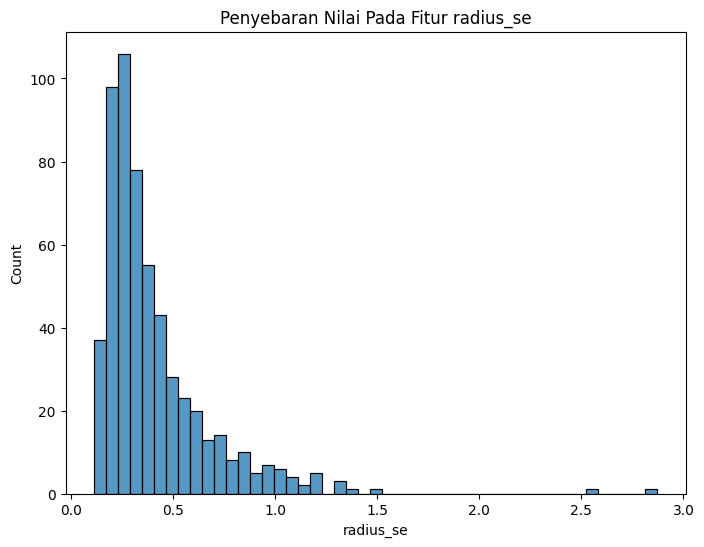

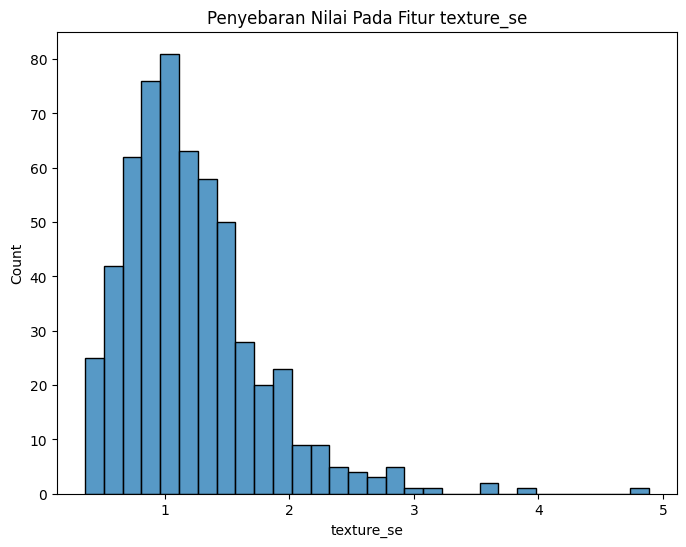

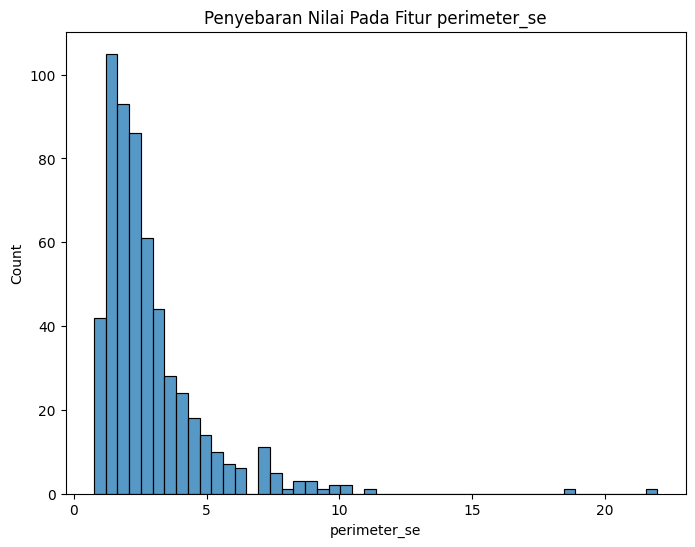

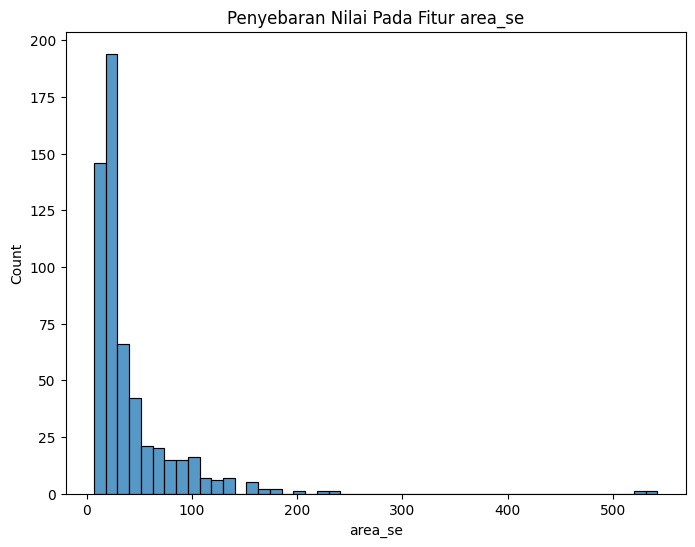

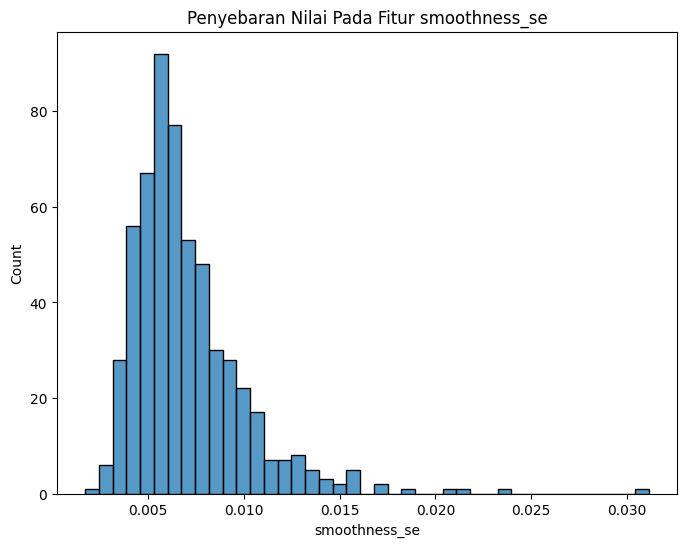

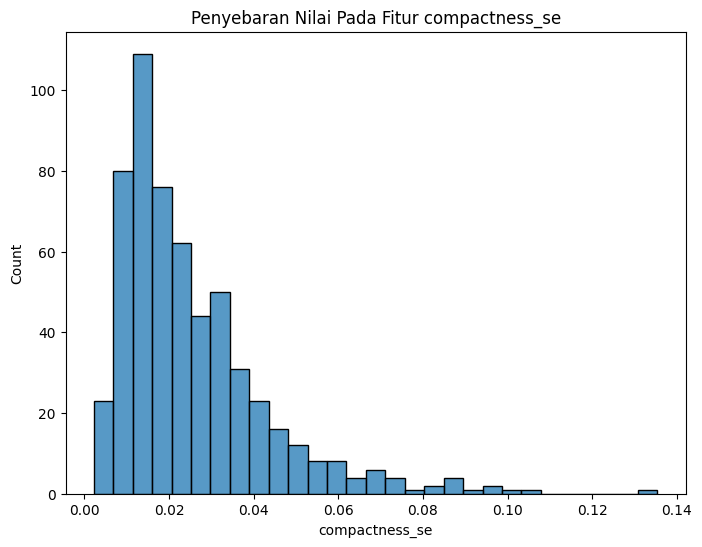

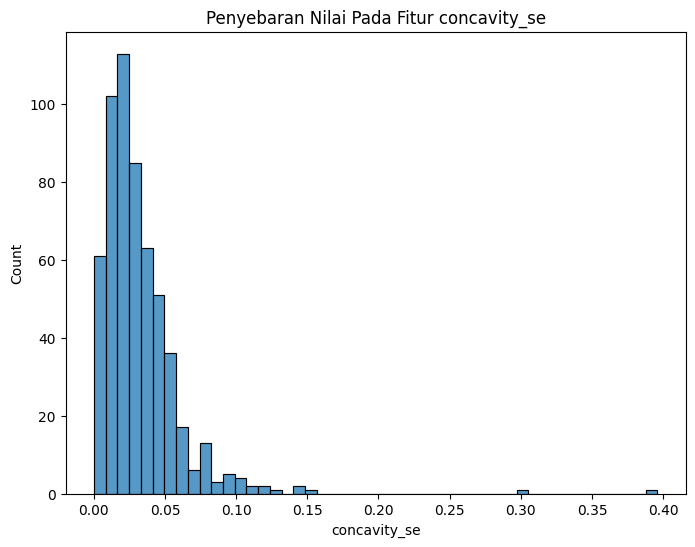

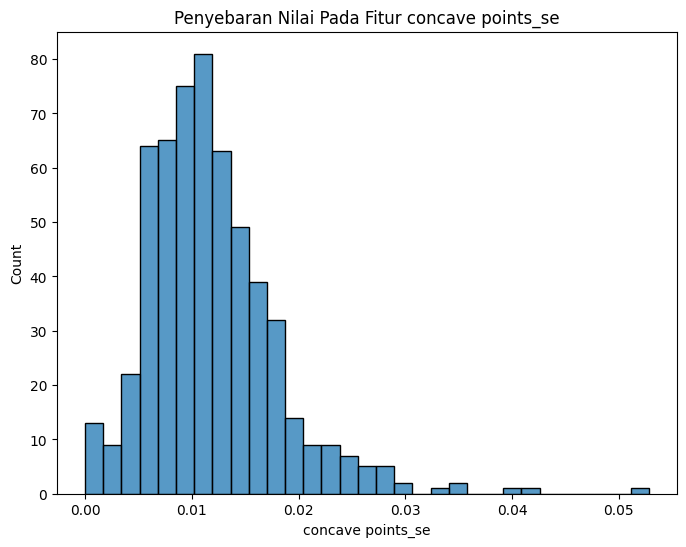

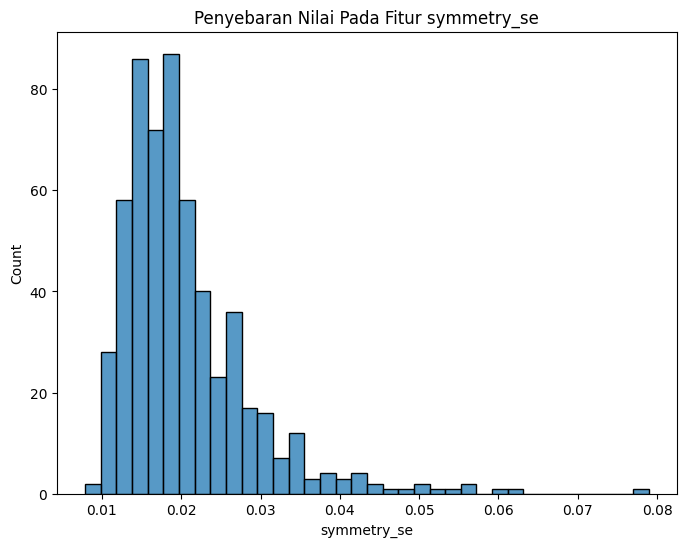

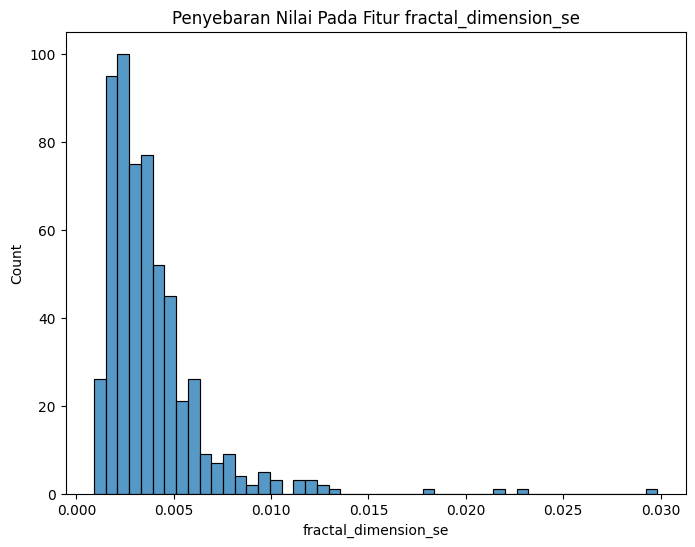

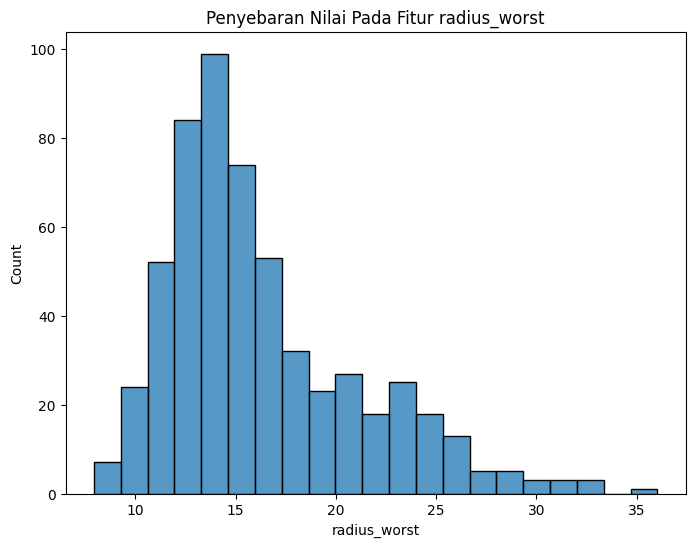

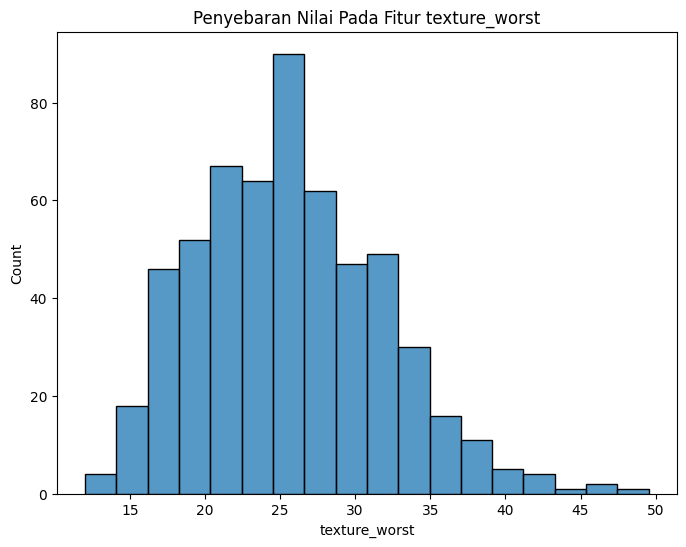

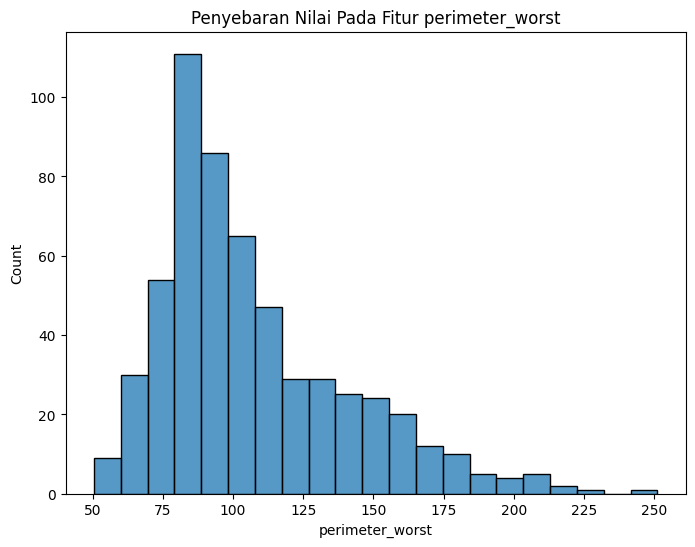

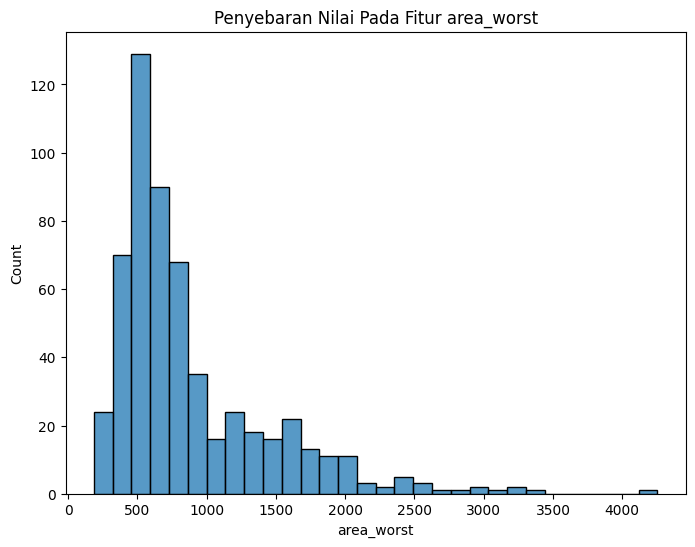

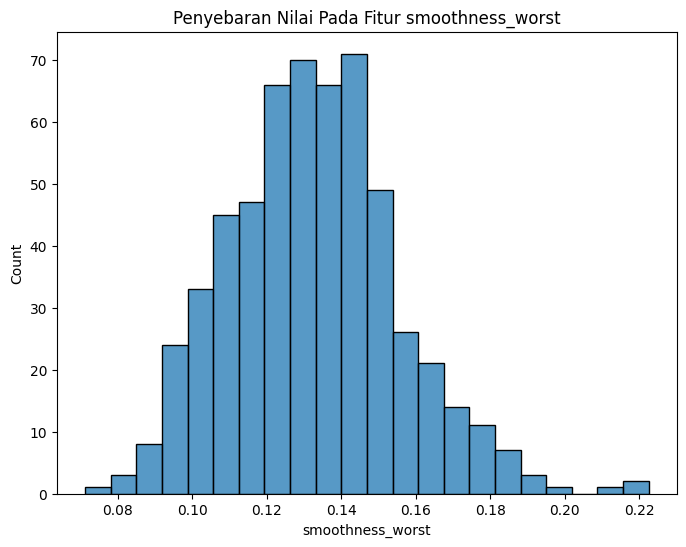

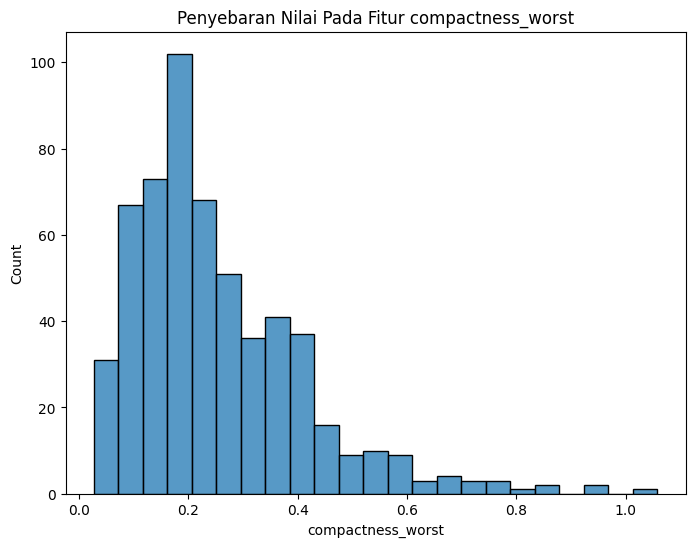

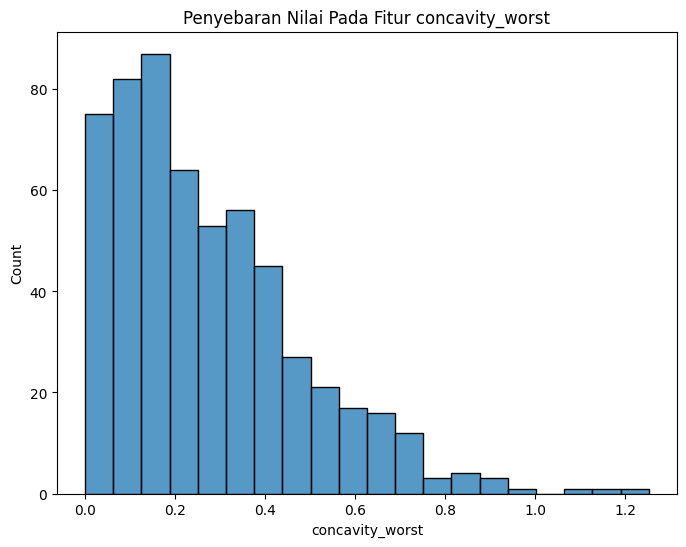

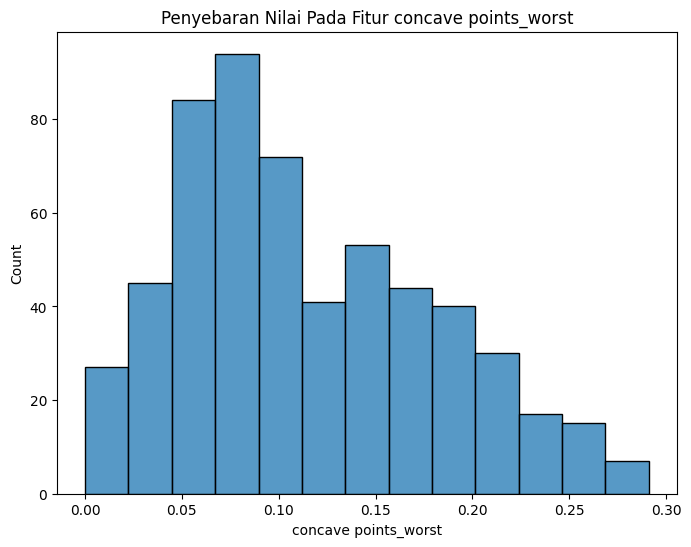

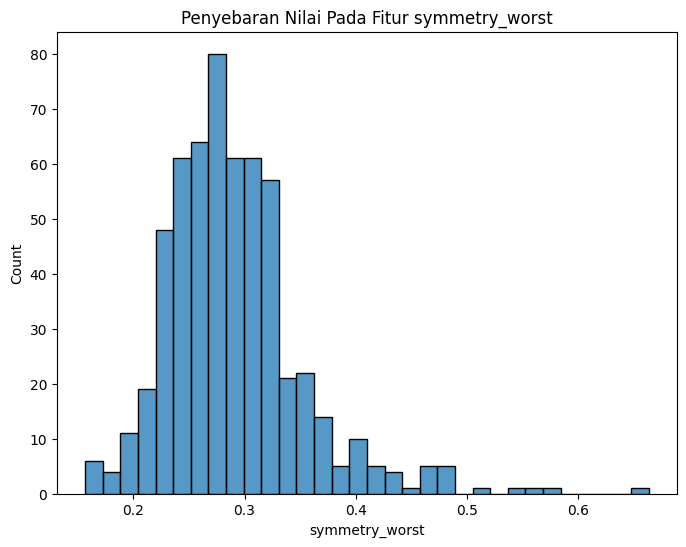

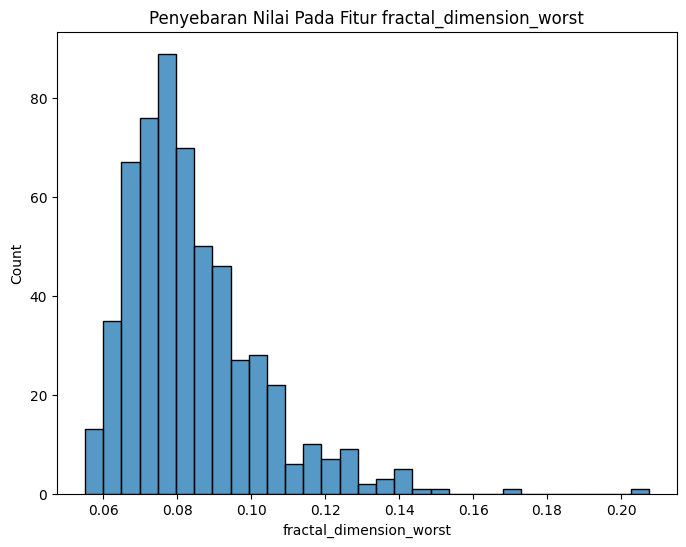

In [17]:
# Penyebaran nilai fitur
for col in cancer.columns:
    plt.figure(figsize=(8, 6))
    sns.histplot(x=cancer[col])
    plt.title(f'Penyebaran Nilai Pada Fitur {col}')
    plt.show()

Penyebaran fitur cenderung skew ke kanan. 

#### 1.4.3 Korelasi antar Fitur

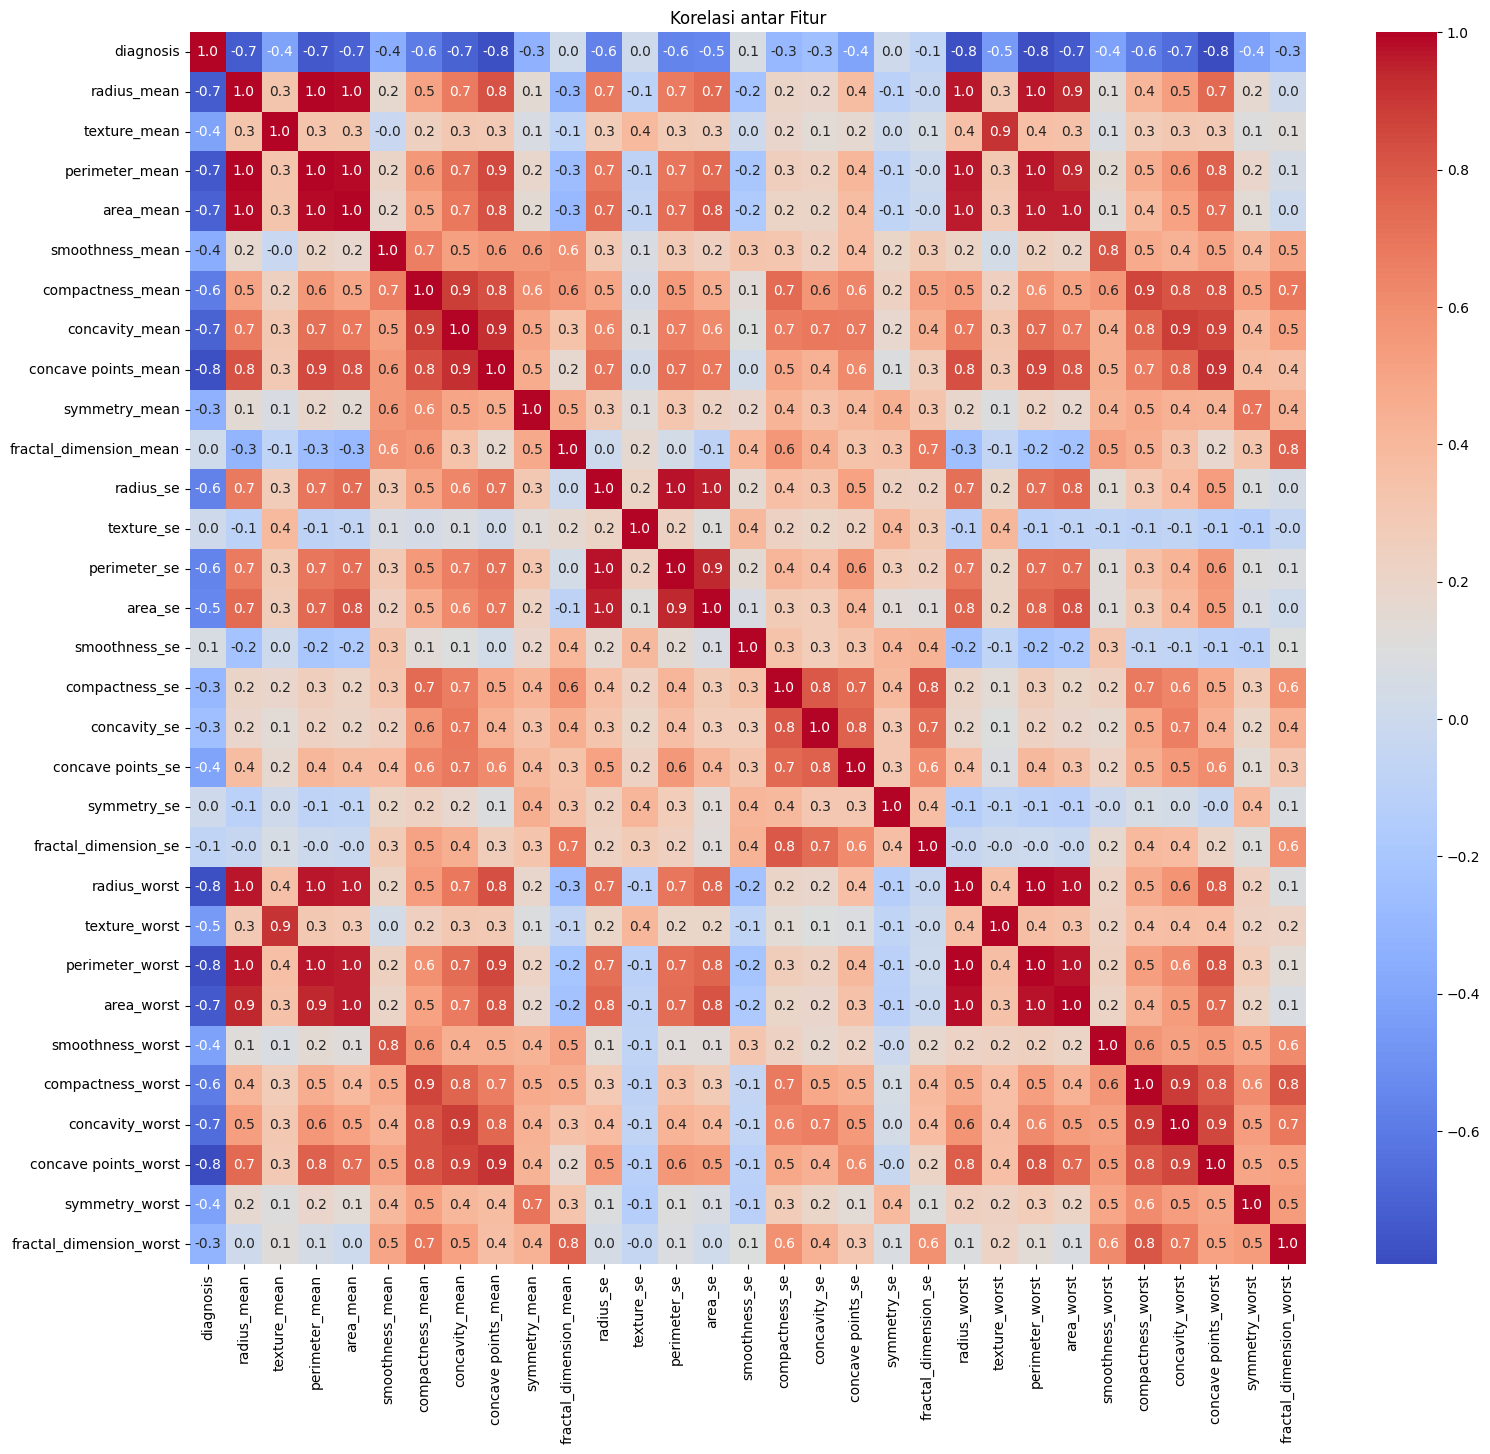

In [18]:
# Tamplikan korelasi antar fitur
correlation = cancer.corr()

# Grafik heatmap
plt.figure(figsize=(18,16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f' )
plt.title('Korelasi antar Fitur')
plt.show()

Banyak dari 2 fitur yang saling berkorelasi tinggi, sedangkan logistic regression sensitif terhadap outlier. Sehingga:
- 2 fitur yang berkorelasi tinggi & salah satu dari 2 fitur yang memiliki nilai paling tinggi dengan fitur target --> Simpan ke variabel.
 

In [19]:
high_corr = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'concavity_mean']

In [20]:
correlation

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,-0.730029,-0.415185,-0.742636,-0.708984,-0.358560,-0.596534,-0.696360,-0.776614,-0.330499,...,-0.776454,-0.456903,-0.782914,-0.733825,-0.421465,-0.590998,-0.659610,-0.793566,-0.416294,-0.323872
radius_mean,-0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,-0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,-0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,-0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,-0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,-0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,-0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,-0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


Terdapat beberapa fitur yang berkorelasi sangat tinggi hingga mencapai 100% terhadap fitur lainnya.

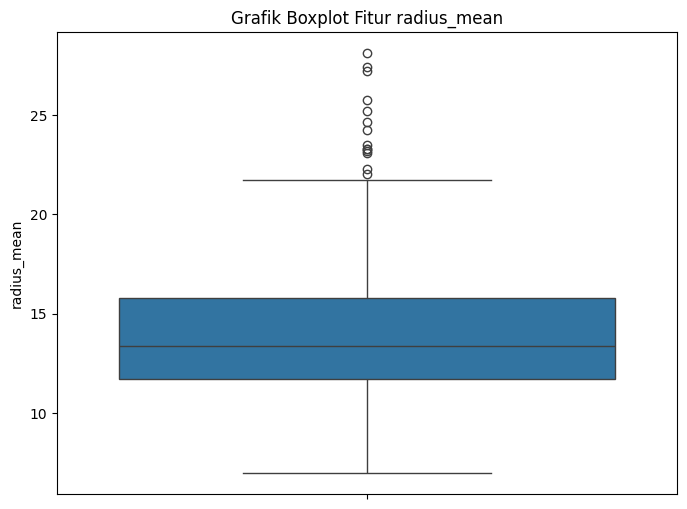

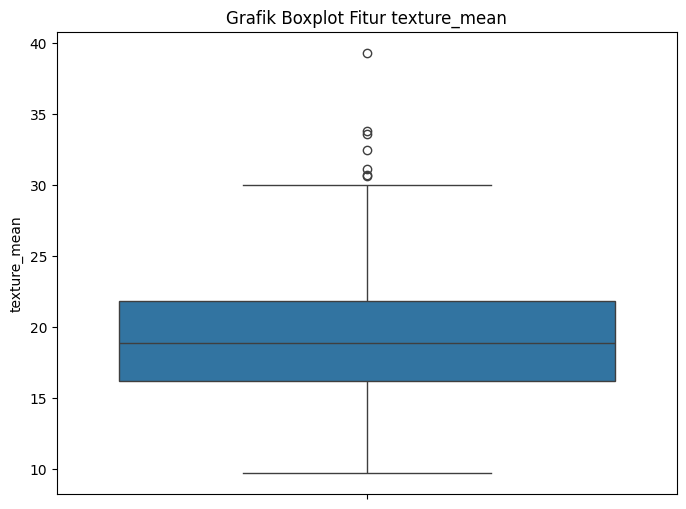

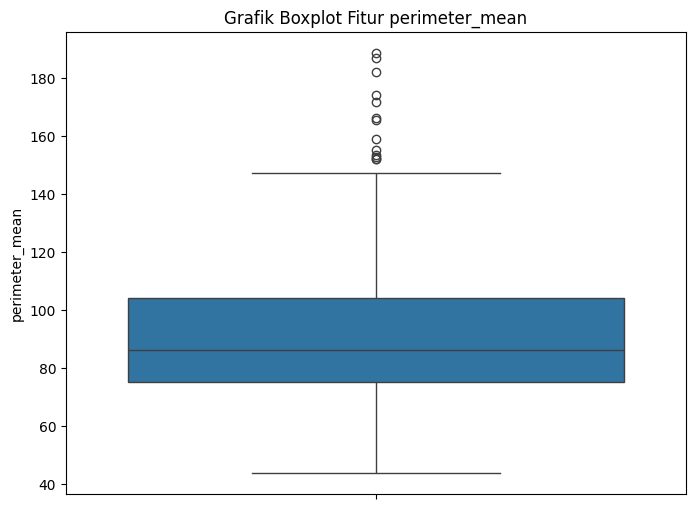

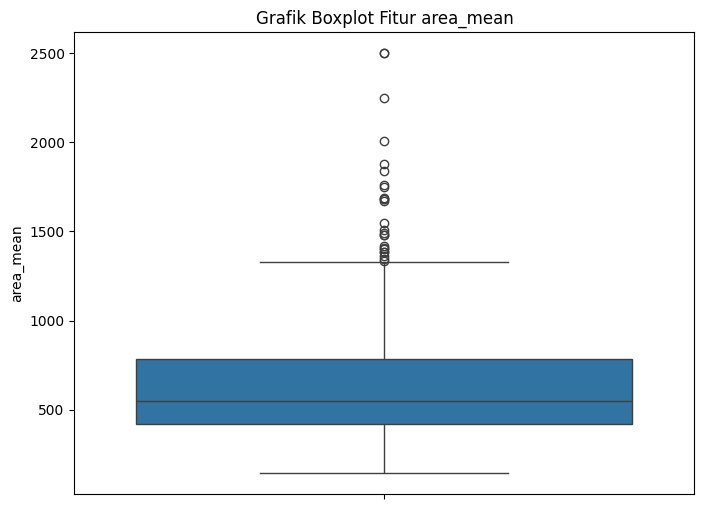

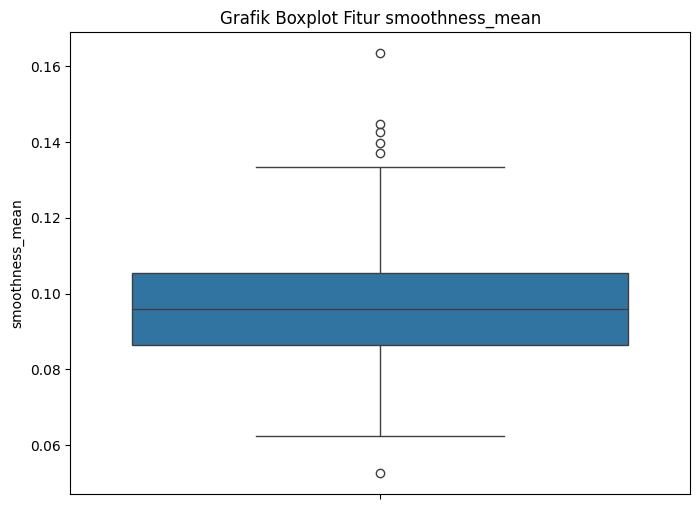

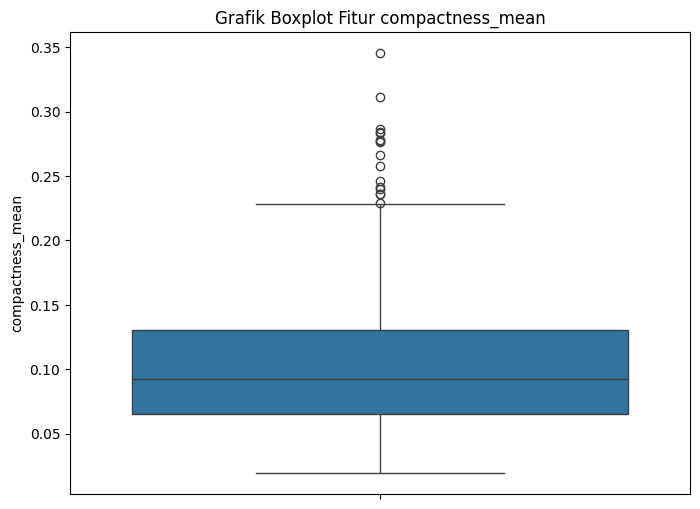

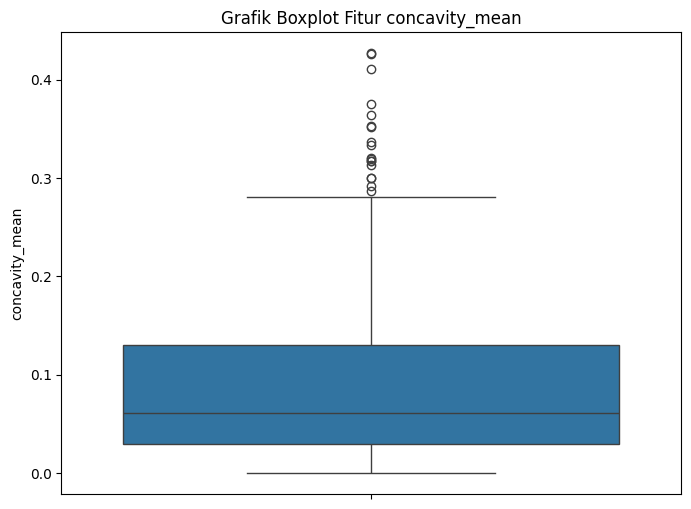

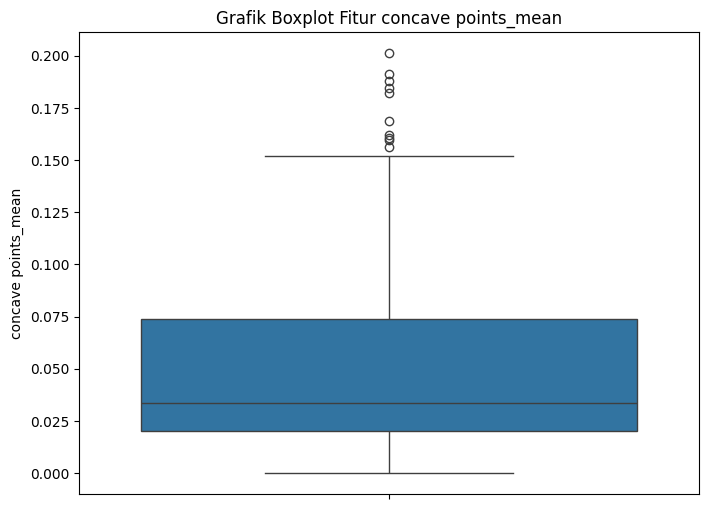

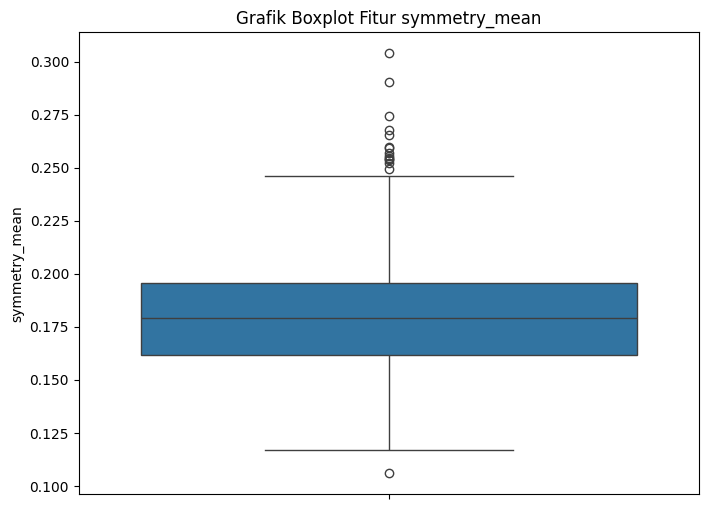

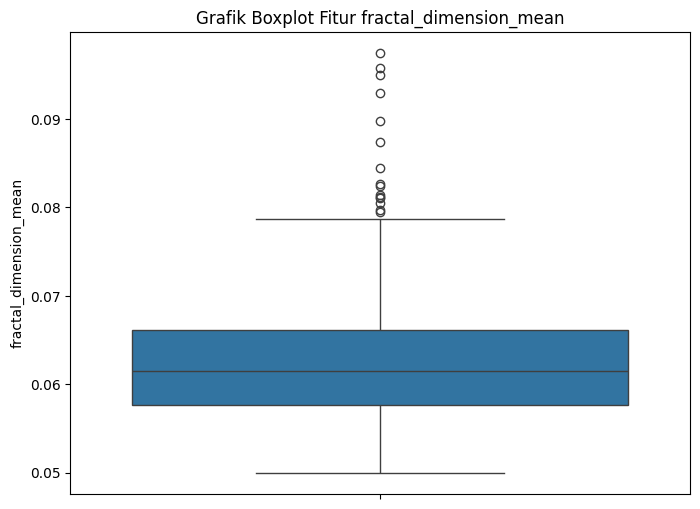

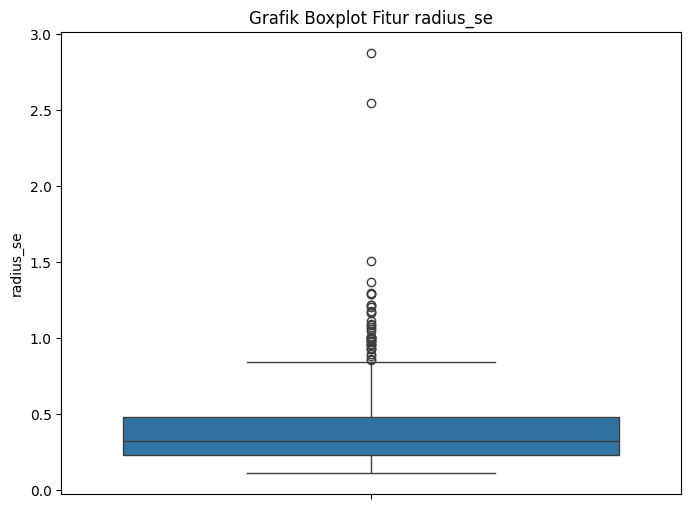

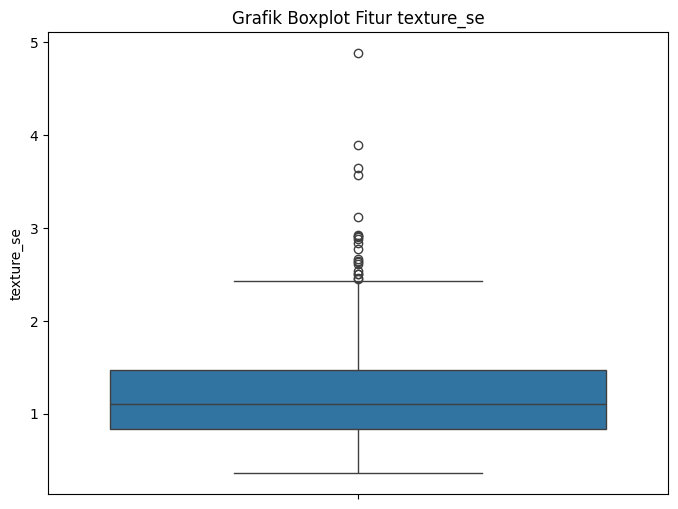

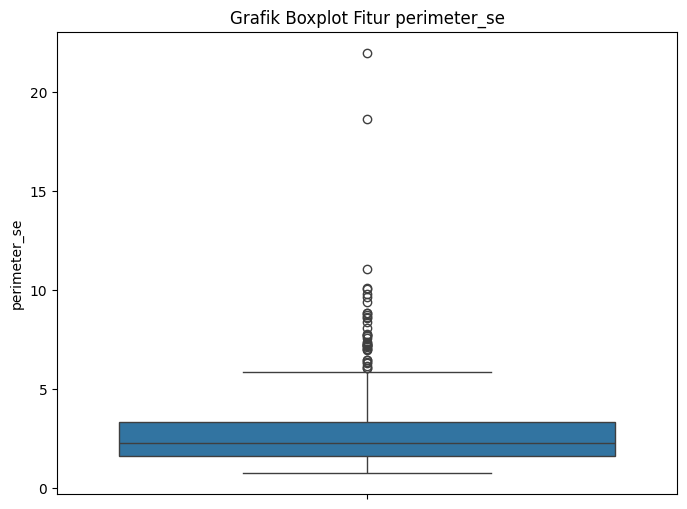

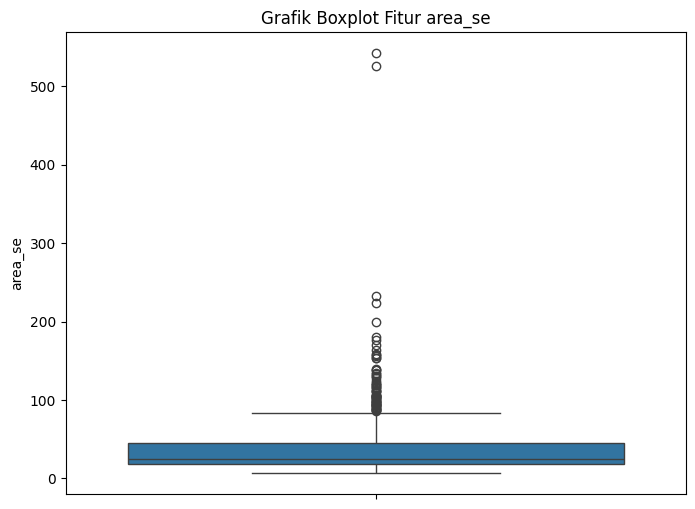

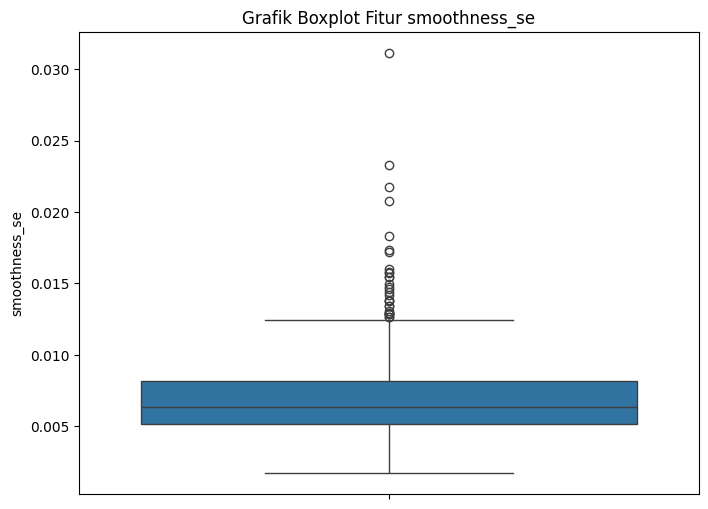

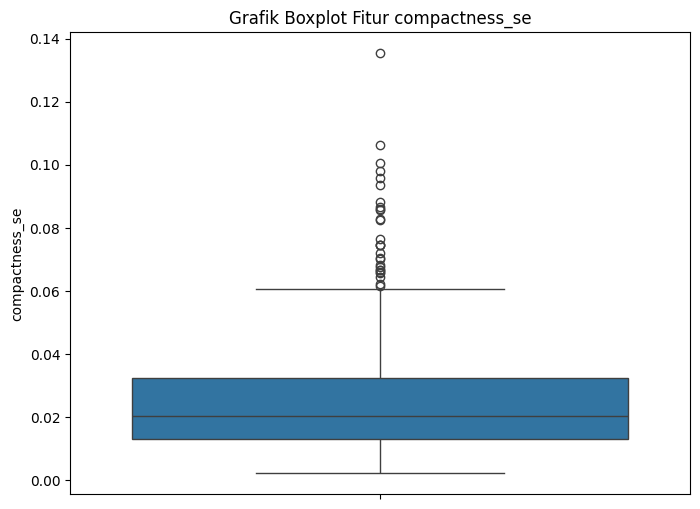

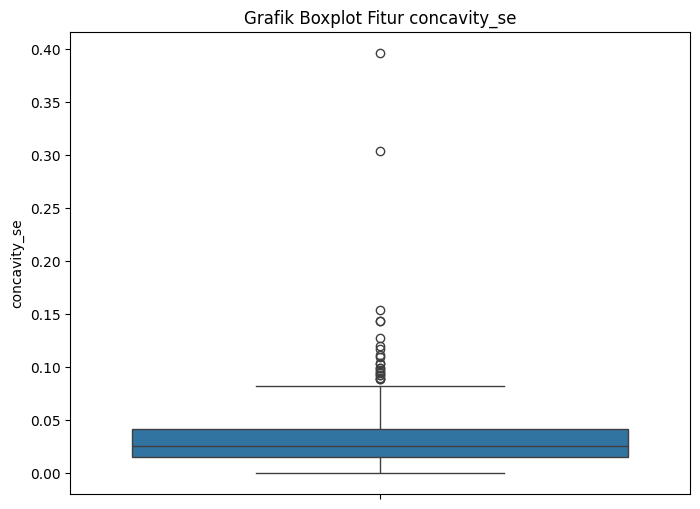

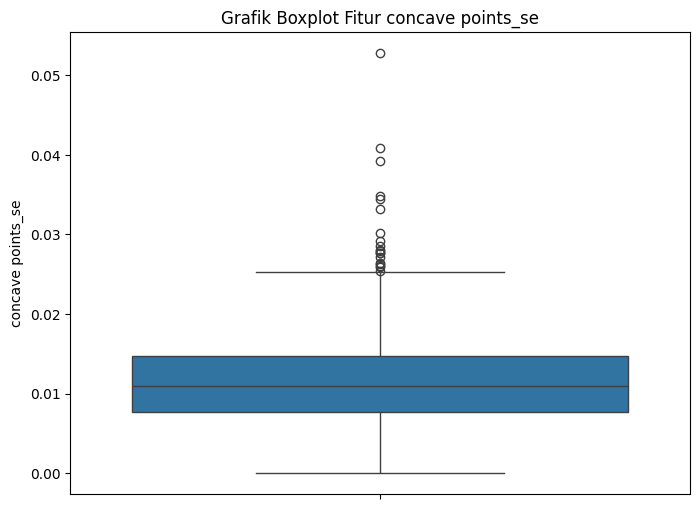

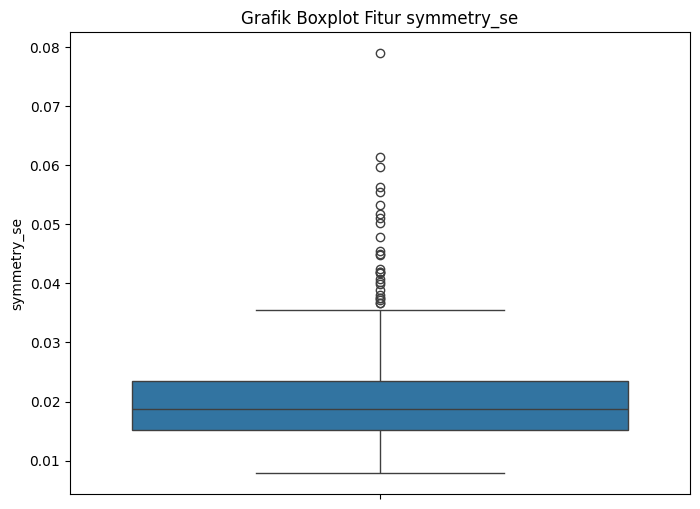

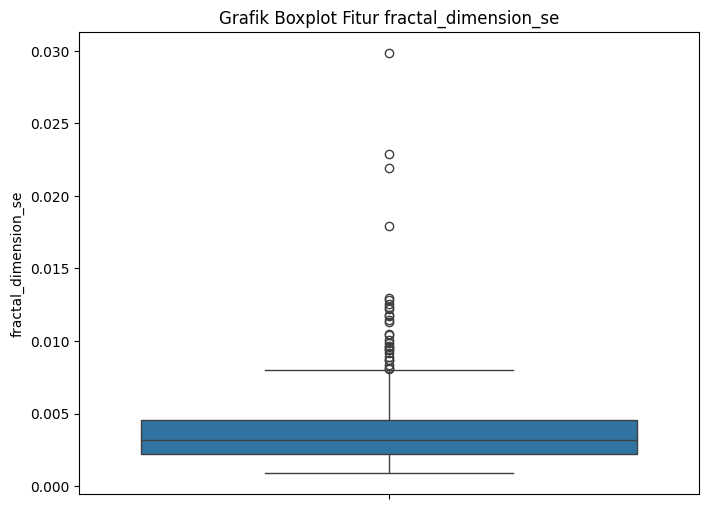

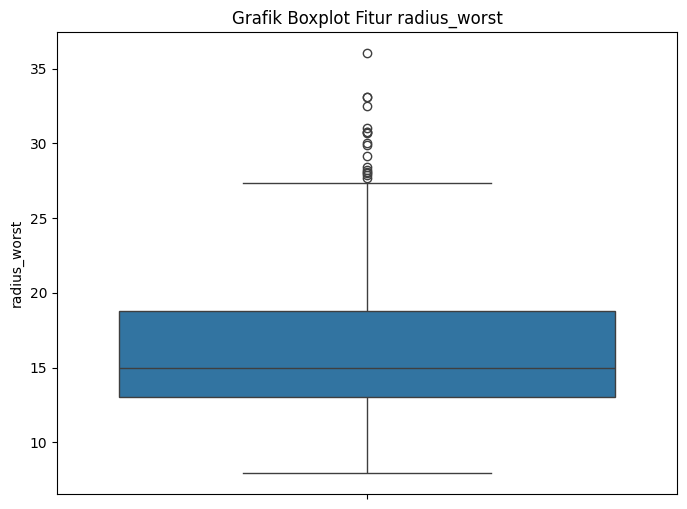

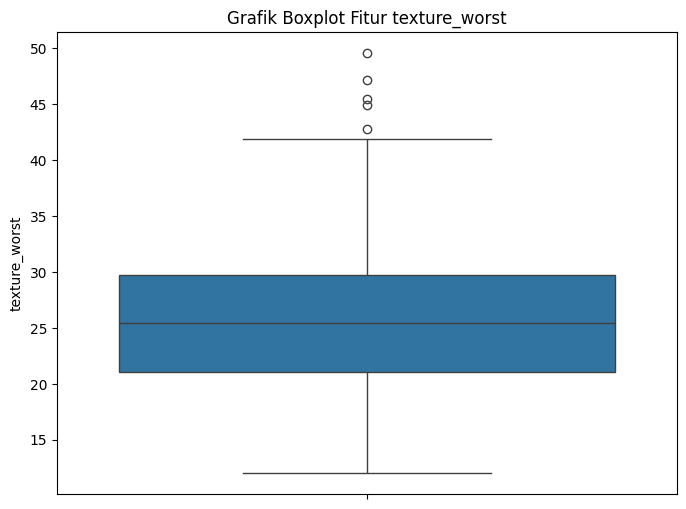

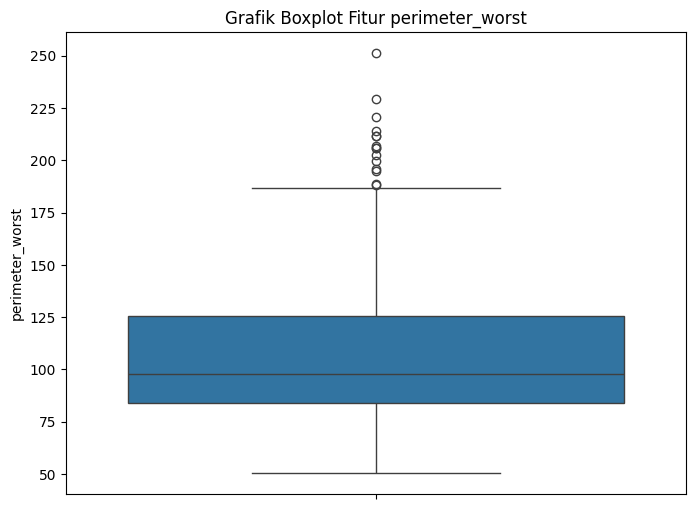

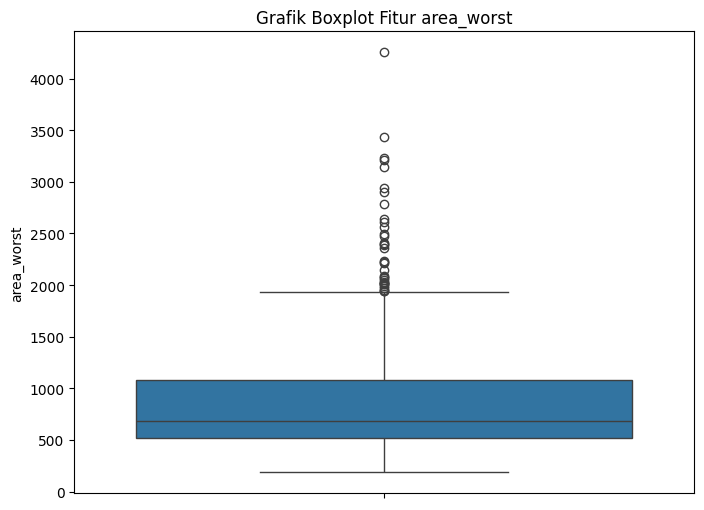

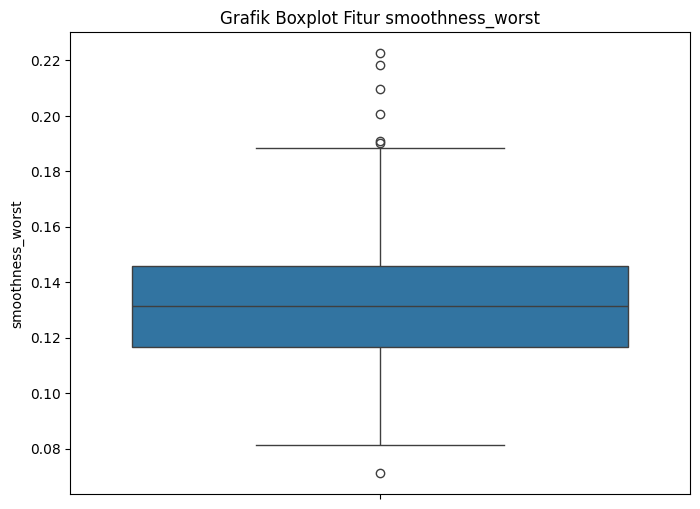

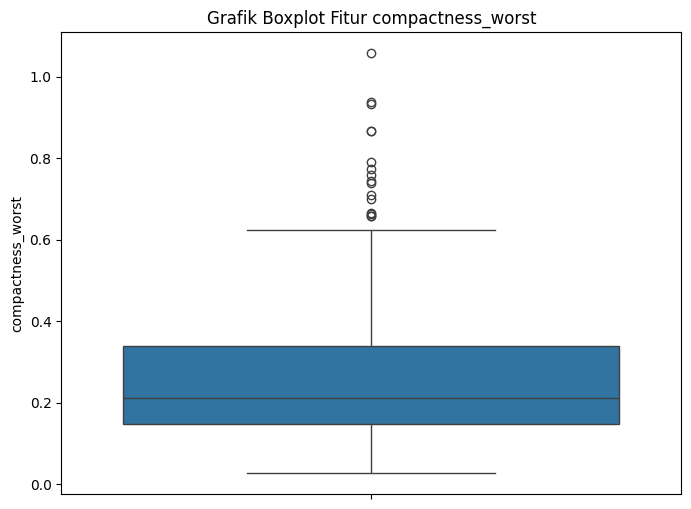

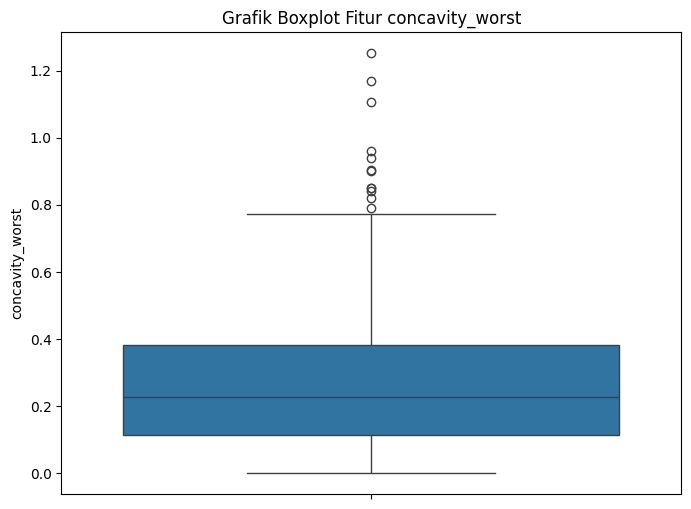

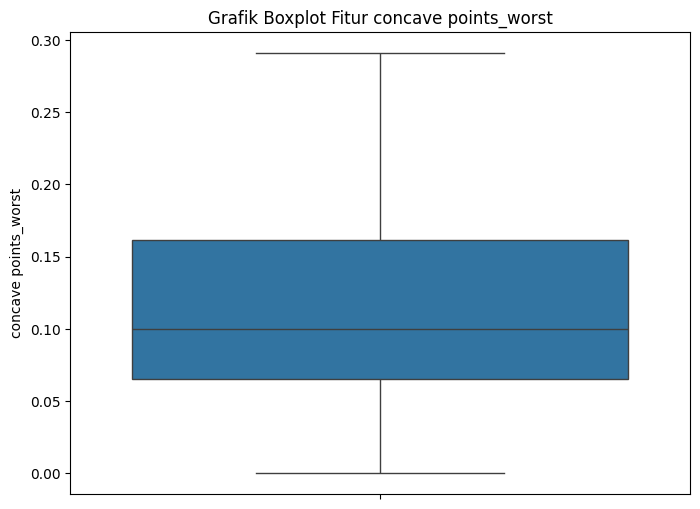

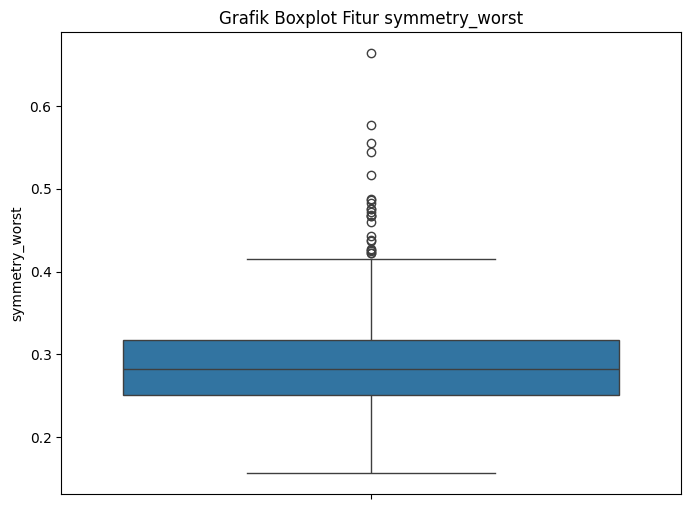

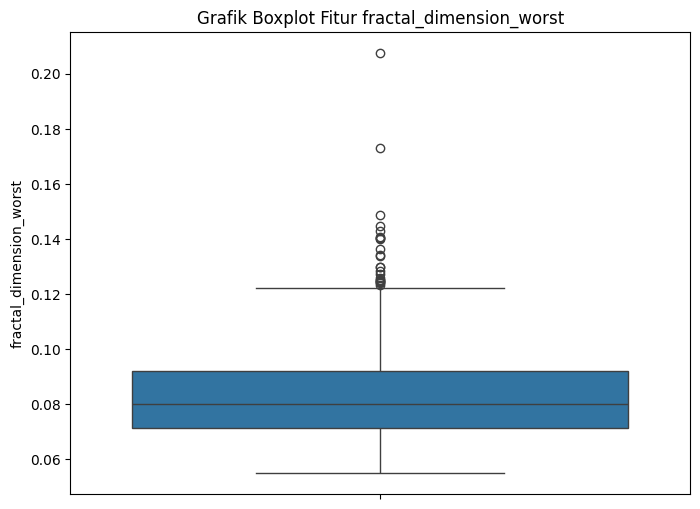

In [21]:
X = cancer.drop('diagnosis', axis=1)

for col in X.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=cancer[col])
    plt.title(f'Grafik Boxplot Fitur {col}')
    plt.show()

Pada dataset ini, semua fitur cenderung memiliki nilai diluar range dan nilai nya cenderung lebih besar dari range. Model logistic cenderung sensitif ke outlier, sehingga kita akan menanganinya.

### 1.5 Data Cleaning

In [22]:
high_corr

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'concavity_mean']

In [23]:
cancer.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [24]:

high_corr = [
    'radius_mean', 'perimeter_mean', 
    'radius_se', 'perimeter_se', 
    'radius_worst', 'perimeter_worst',
    'perimeter_mean', 'perimeter_worst'
]

# Menghapus dengan filter kolom yang tersedia
cancer = cancer.drop(columns=[col for col in high_corr if col in cancer.columns])

print(f"Sisa kolom: {cancer.shape[1]}")

Sisa kolom: 25


In [25]:
cancer.shape[1]

25

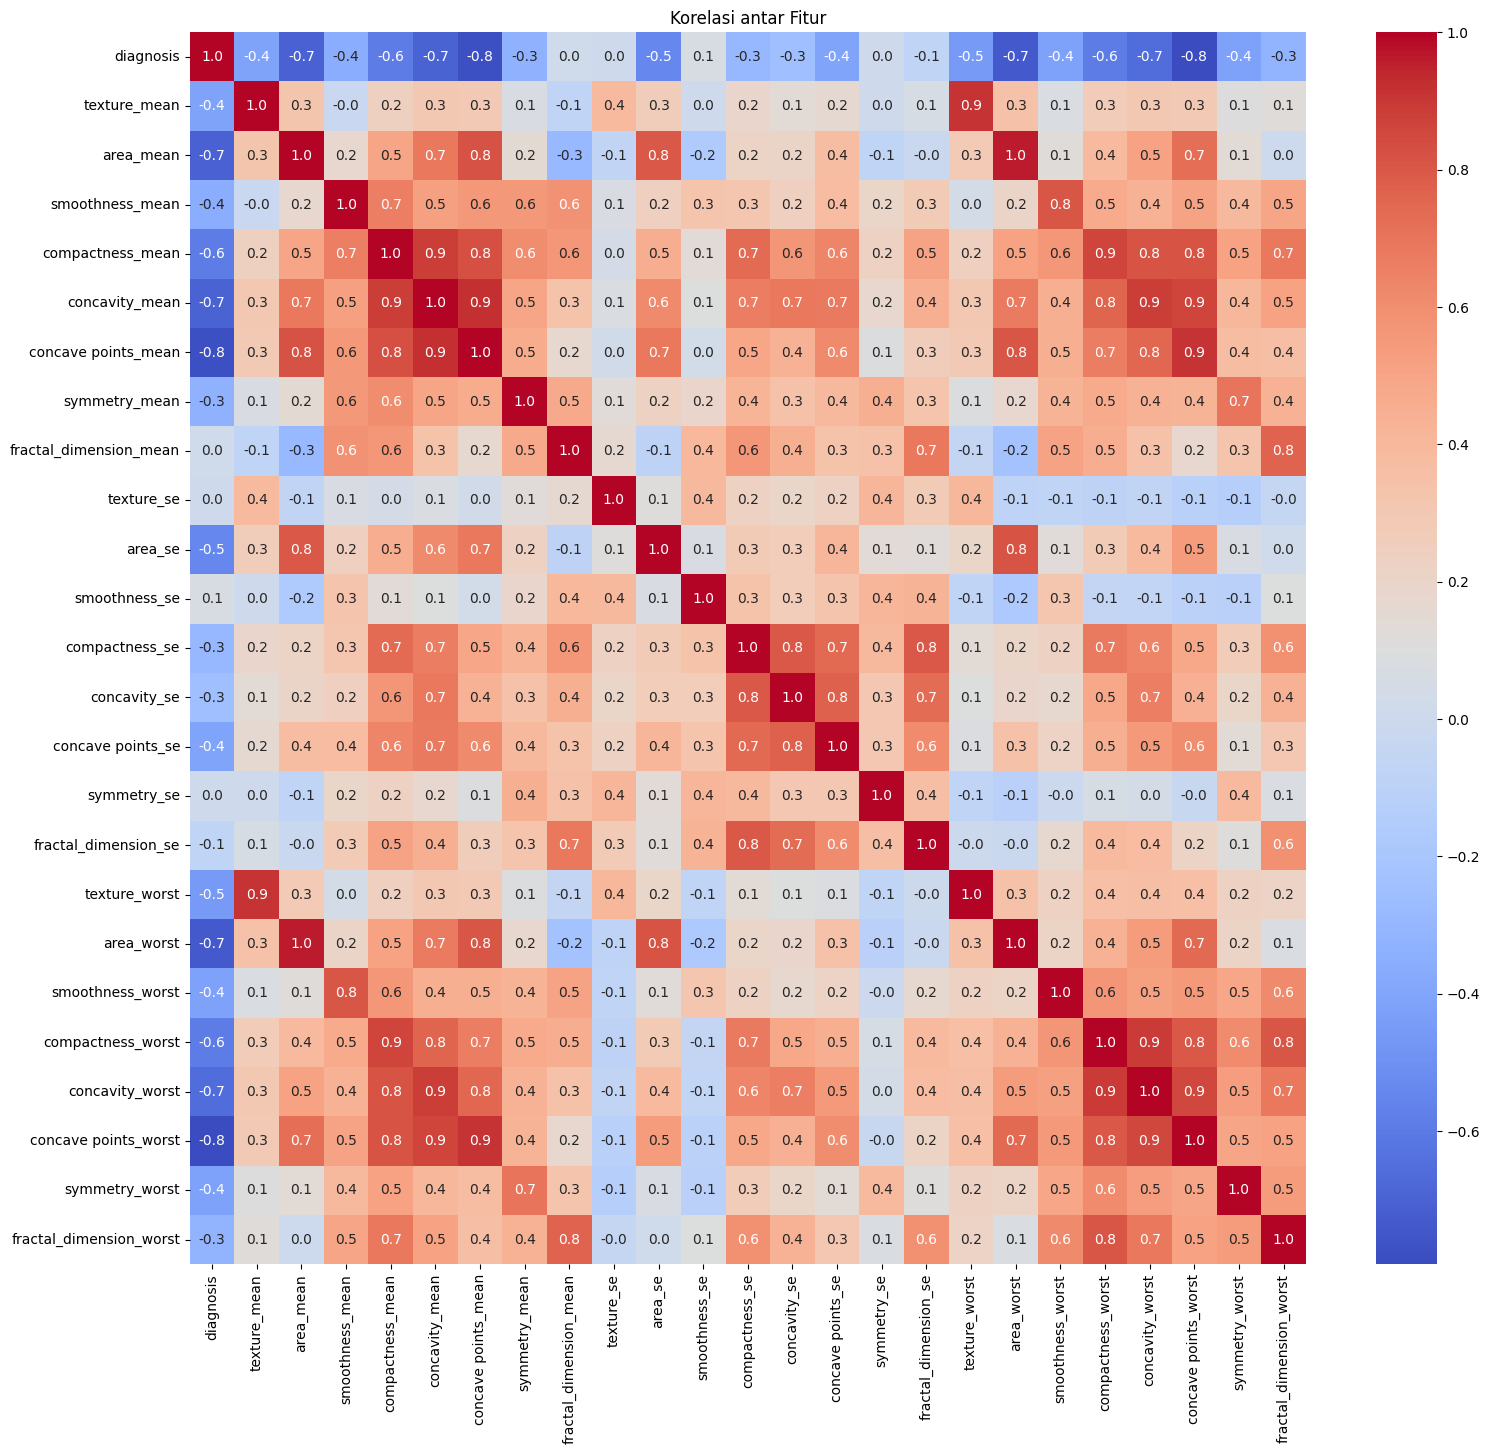

In [26]:
# Tamplikan korelasi antar fitur
correlation = cancer.corr()

# Grafik heatmap
plt.figure(figsize=(18,16))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f' )
plt.title('Korelasi antar Fitur')
plt.show()

In [27]:
correlation

,diagnosis,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,...,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,-0.415185,-0.708984,-0.358560,-0.596534,-0.696360,-0.776614,-0.330499,0.012838,0.008303,...,0.006522,-0.077972,-0.456903,-0.733825,-0.421465,-0.590998,-0.659610,-0.793566,-0.416294,-0.323872
texture_mean,-0.415185,1.000000,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.386358,...,0.009127,0.054458,0.912045,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
area_mean,-0.708984,0.321086,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,-0.066280,...,-0.072497,-0.019887,0.287489,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,-0.358560,-0.023389,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.068406,...,0.200774,0.283607,0.036072,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,-0.596534,0.236702,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.046205,...,0.229977,0.507318,0.248133,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,-0.696360,0.302418,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.076218,...,0.178009,0.449301,0.299879,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,-0.776614,0.293464,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.021480,...,0.095351,0.257584,0.292752,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,-0.330499,0.071401,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.128053,...,0.449137,0.331786,0.090651,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,0.012838,-0.076437,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,0.164174,...,0.345007,0.688132,-0.051269,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297
texture_se,0.008303,0.386358,-0.066280,0.068406,0.046205,0.076218,0.021480,0.128053,0.164174,1.000000,...,0.411621,0.279723,0.409003,-0.083195,-0.073658,-0.092439,-0.068956,-0.119638,-0.128215,-0.045655


In [28]:

for col in cancer.columns:
    # Memeriksa: Jika kolom BUKAN diagnosis, maka lakukan proses Log + IQR
    if col != 'diagnosis':
        # Log Transformation
        cancer[col] = np.log1p(cancer[col])

        # Hitung IQR pada data yang sudah di-log
        Q1 = cancer[col].quantile(0.25)
        Q3 = cancer[col].quantile(0.75)
        IQR = Q3 - Q1 

        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR
        
        # Clipping sisa outlier
        cancer[col] = cancer[col].clip(lower=batas_bawah, upper=batas_atas)

In [29]:
cancer['diagnosis'].value_counts()

diagnosis
1    357
0    212
Name: count, dtype: int64

## 2. Model

### 2.1 Independent & Dependent

In [30]:
X = cancer.drop('diagnosis', axis=1)
y = cancer['diagnosis']

### 2.2 Feature Scaling 

In [31]:
# # Normalisasi
X = (X - X.min()) / (X.max() - X.min())

# # Standarisasi
# X = (X - X.mean()) / X - X.std()

### 2.3 Startified Split Data

In [32]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X.iloc[train_idx].values
y_train = y.iloc[train_idx].values
X_test = X.iloc[test_idx].values
y_test = y.iloc[test_idx].values

### 2.4 Resampling Target

In [33]:
np.random.seed(42)

cancer_major = cancer[cancer['diagnosis'] == 1]
cancer_minor = cancer[cancer['diagnosis'] == 0]

n_major = len(cancer_major)
n_minor = len(cancer_minor)

indeks_minor = cancer_minor.index

indeks_random = np.random.choice(indeks_minor, size=n_major, replace=True)
cancer_minor_over = cancer.loc[indeks_random]
cancer = pd.concat([cancer_major, cancer_minor_over])


### 2.5 Linear Regression

In [34]:
def linear(X, w,b):
    z = np.dot(X, w) + b
    return z

### 2.6 Sigmoid

In [35]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### 2.7 Loss Function

In [36]:
def log_loss(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(y_true  * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

### 2.8 Gradient Descent

In [37]:
def gradient(X, y_true, y_pred):
    m = X.shape[0]
    error = y_pred - y_true
    dw = (1 / m) * np.dot(X.T, error)
    db = (1 / m) * np.sum(error)
    return dw, db

### 2.9 Update Parameter

In [38]:
def update_parameter(w, b, dw, db, learning_rate):
    w_new = w - learning_rate * dw
    b_new = b - learning_rate * db

    return w_new, b_new

### 2.10 Inisialisasi Fungsi

In [39]:
w = np.zeros(X_train.shape[1])
b = 0 
learning_rate = 15
ephocs = 500
loss_history = []

for i in range(ephocs):
    z = linear(X_train, w, b)
    y_pred = sigmoid(z)

    loss_value = log_loss(y_train, y_pred)
    loss_history.append(loss_value)

    dw, db = gradient(X_train, y_train, y_pred)

    w, b = update_parameter(w, b, dw, db, learning_rate)

    if i % 50 == 0:
        print(f"epoch : {i}, loss : {loss_value:.4f}")

print(f"\nHasil Akhir: {loss_value:.4f}")

epoch : 0, loss : 0.6931
epoch : 50, loss : 0.1300
epoch : 100, loss : 0.0694
epoch : 150, loss : 0.0581
epoch : 200, loss : 0.0541
epoch : 250, loss : 0.0518
epoch : 300, loss : 0.0503
epoch : 350, loss : 0.0490
epoch : 400, loss : 0.0480
epoch : 450, loss : 0.0471

Hasil Akhir: 0.0463


## **EVALUASI**

### 3.1 Prediksi

In [40]:
def prediksi(X, w, b, threshold=0.7):
    z = linear(X, w, b)
    y_prob = sigmoid(z)

    y_class = [1 if p > threshold else 0 for p in y_prob]

    return np.array(y_class)

### 3.1 Fungsi Evaluasi

In [41]:
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) /  (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1

### 3.2 Prediksi Train

In [42]:
prediksi_train = prediksi(X_train, w, b)
akurasi_train = np.sum(prediksi_train == y_train) / len(X_train)
print(f"Akurasi train : {akurasi_train:.4f}")

Akurasi train : 0.9802


### 3.3 Prediksi Test

In [43]:
prediksi_test = prediksi(X_test, w, b)
akurasi_test = np.sum(prediksi_test == y_test) / len(X_test)
print(f"Akurasi test : {akurasi_test:.4f}")

Akurasi test : 0.9478


### 3.4 Presisi, Recall, F1

In [44]:
_, precision_train, recall_train, f1_train = evaluate(y_train, prediksi_train)
_, precision_test, recall_test, f1_test = evaluate(y_test, prediksi_test)

print(f"Train\nPresisi: {precision_train:.4f}\nRecall: {recall_train:.4f}\nF1: {f1_train:.4f}")
print(f"\n\nTest\nPresisi: {precision_test:.4f}\nRecall: {recall_test:.4f}\nF1: {f1_test:.4f}")

Train
Presisi: 0.9894
Recall: 0.9789
F1: 0.9841


Test
Presisi: 0.9853
Recall: 0.9306
F1: 0.9571


## **VISUALISASI**

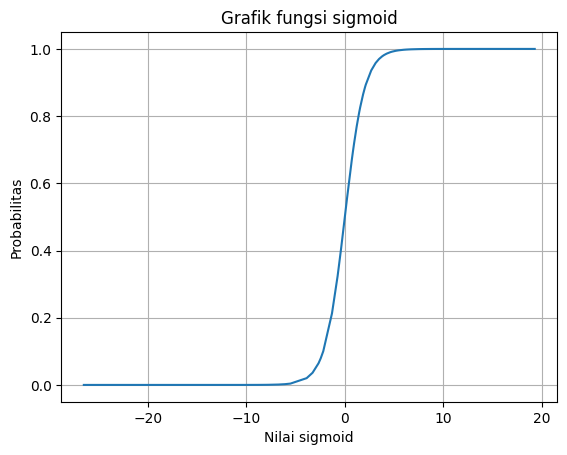

In [45]:
z_1 = np.dot(X_test, w) + b
z_sort = np.sort(z_1)
z_sorted = sigmoid(z_sort)

plt.plot(z_sort, z_sorted)
plt.grid(True)
plt.title('Grafik fungsi sigmoid')
plt.xlabel('Nilai sigmoid')
plt.ylabel('Probabilitas')
plt.show()

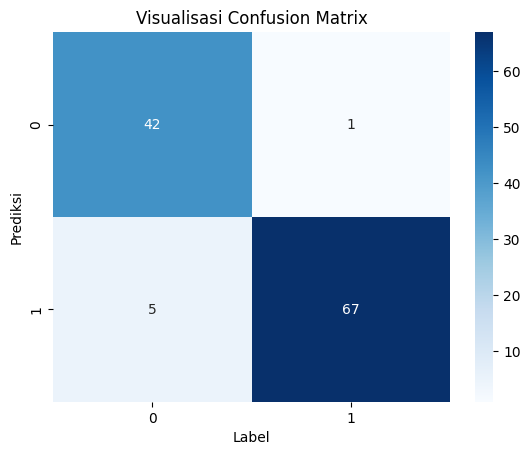

In [46]:
def confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate((y_true, y_pred)))
    label_idx = {label: i for i, label in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        i = label_idx[yt]
        j = label_idx[yp]
        cm[i, j] += 1
    return cm, labels

cm, labels = confusion_matrix(y_test, prediksi_test)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Label')
plt.ylabel('Prediksi')
plt.title('Visualisasi Confusion Matrix')
plt.show()